# Chimera Image EDA — Whole Slide Image Exploration

**Dataset:** 95 prostate-cancer patients, 190 WSI pyramidal TIFFs

**Goal:** Preliminary image-level analysis using thumbnail and tissue mask previews,
without relying on clinical labels.

## Imports

In [ ]:
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
import tifffile

plt.rcParams.update({"figure.dpi": 120, "figure.max_open_warning": 0})

In [ ]:
WSI_DIR    = Path("../Chimera_data_task1/pathology/images")

SAMPLE_ID    = "1003"
SAMPLE_SLIDE = "1003_1"
WSI_LEVEL    = 4   # 256× downsample, 660×418 for 1003_1
MASK_LEVEL   = -1  # coarsest mask level (index 6), identical dimensions

## Single WSI pyramid level

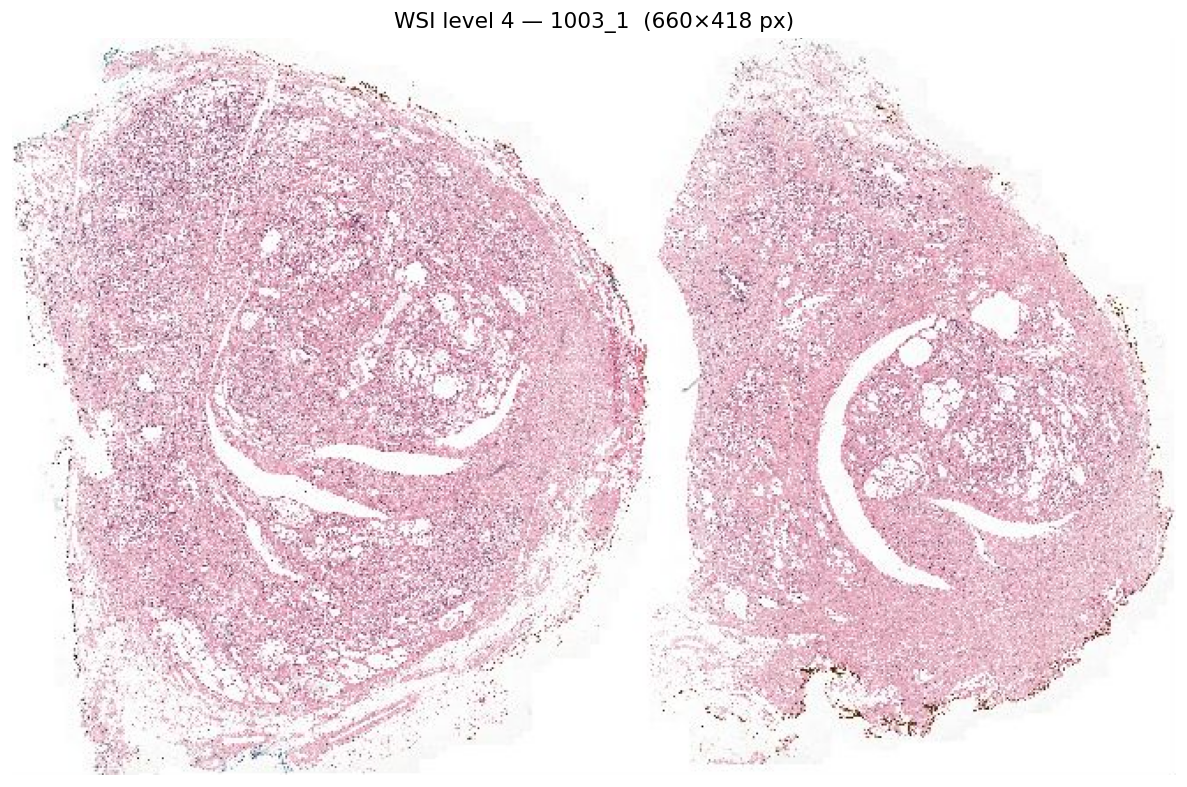

In [ ]:
wsi_path = WSI_DIR / SAMPLE_ID / f"{SAMPLE_SLIDE}.tif"

with tifffile.TiffFile(str(wsi_path)) as tif:
    thumb_arr = tif.pages[WSI_LEVEL].asarray()

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(thumb_arr)
ax.set_title(f"WSI level {WSI_LEVEL} — {SAMPLE_SLIDE}  ({thumb_arr.shape[1]}×{thumb_arr.shape[0]} px)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## Pyramid structure of a TIFF

In [ ]:
wsi_path = WSI_DIR / SAMPLE_ID / f"{SAMPLE_SLIDE}.tif"

with tifffile.TiffFile(str(wsi_path)) as tif:
    print(f"WSI — {SAMPLE_SLIDE}.tif")
    print(f"  Pages (pyramid levels): {len(tif.pages)}")
    for i, page in enumerate(tif.pages):
        w = page.tags["ImageWidth"].value
        h = page.tags["ImageLength"].value
        ds = round(tif.pages[0].tags["ImageWidth"].value / w)
        print(f"  Level {i}: {w:>7} × {h:<7}  ({ds}× downsample)")

mask_path = WSI_DIR / SAMPLE_ID / f"{SAMPLE_SLIDE}_tissue.tif"

with tifffile.TiffFile(str(mask_path)) as tif:
    print(f"\nMask — {SAMPLE_SLIDE}_tissue.tif")
    print(f"  Pages (pyramid levels): {len(tif.pages)}")
    for i, page in enumerate(tif.pages):
        w = page.tags["ImageWidth"].value
        h = page.tags["ImageLength"].value
        ds = round(tif.pages[0].tags["ImageWidth"].value / w)
        print(f"  Level {i}: {w:>7} × {h:<7}  ({ds}× downsample)")

WSI — 1003_1.tif
  Pages (pyramid levels): 5
  Level 0:  168960 × 107008   (1× downsample)
  Level 1:   42240 × 26752    (4× downsample)
  Level 2:   10560 × 6688     (16× downsample)
  Level 3:    2640 × 1672     (64× downsample)
  Level 4:     660 × 418      (256× downsample)

Mask — 1003_1_tissue.tif
  Pages (pyramid levels): 7
  Level 0:   42240 × 26752    (1× downsample)
  Level 1:   21120 × 13376    (2× downsample)
  Level 2:   10560 × 6688     (4× downsample)
  Level 3:    5280 × 3344     (8× downsample)
  Level 4:    2640 × 1672     (16× downsample)
  Level 5:    1320 × 836      (32× downsample)
  Level 6:     660 × 418      (64× downsample)


## Aspect ratio check

In [ ]:
# Confirm WSI level 4 and mask coarsest level are pixel-identical in shape
with tifffile.TiffFile(str(wsi_path)) as tif:
    wsi_lv_w = tif.pages[WSI_LEVEL].tags["ImageWidth"].value
    wsi_lv_h = tif.pages[WSI_LEVEL].tags["ImageLength"].value

with tifffile.TiffFile(str(mask_path)) as tif:
    mask_lv_w = tif.pages[MASK_LEVEL].tags["ImageWidth"].value
    mask_lv_h = tif.pages[MASK_LEVEL].tags["ImageLength"].value

print(f"WSI  level {WSI_LEVEL}   : {wsi_lv_w} × {wsi_lv_h} px")
print(f"Mask level {MASK_LEVEL if MASK_LEVEL >= 0 else '(last)'}: {mask_lv_w} × {mask_lv_h} px")
print()
if (wsi_lv_w, wsi_lv_h) == (mask_lv_w, mask_lv_h):
    print("✓ Identical — no resize needed")
else:
    print(f"✗ Mismatch — resize required ({wsi_lv_w - mask_lv_w}px W, {wsi_lv_h - mask_lv_h}px H)")

WSI  level 4   : 660 × 418 px
Mask level (last): 660 × 418 px

✓ Identical — no resize needed


## Tissue mask + masked thumbnail

In [ ]:
mask_path = WSI_DIR / SAMPLE_ID / f"{SAMPLE_SLIDE}_tissue.tif"

with tifffile.TiffFile(str(mask_path)) as tif:
    mask_arr = tif.pages[MASK_LEVEL].asarray()

print(f"WSI level {WSI_LEVEL} size : {thumb_arr.shape[1]}×{thumb_arr.shape[0]} px")
print(f"Mask size        : {mask_arr.shape[1]}×{mask_arr.shape[0]} px")
print(f"Mask values      : {np.unique(mask_arr)}")
print(f"Tissue fraction  : {mask_arr.mean():.1%}")

WSI level 4 size : 660×418 px
Mask size        : 660×418 px
Mask values      : [0 1]
Tissue fraction  : 67.5%


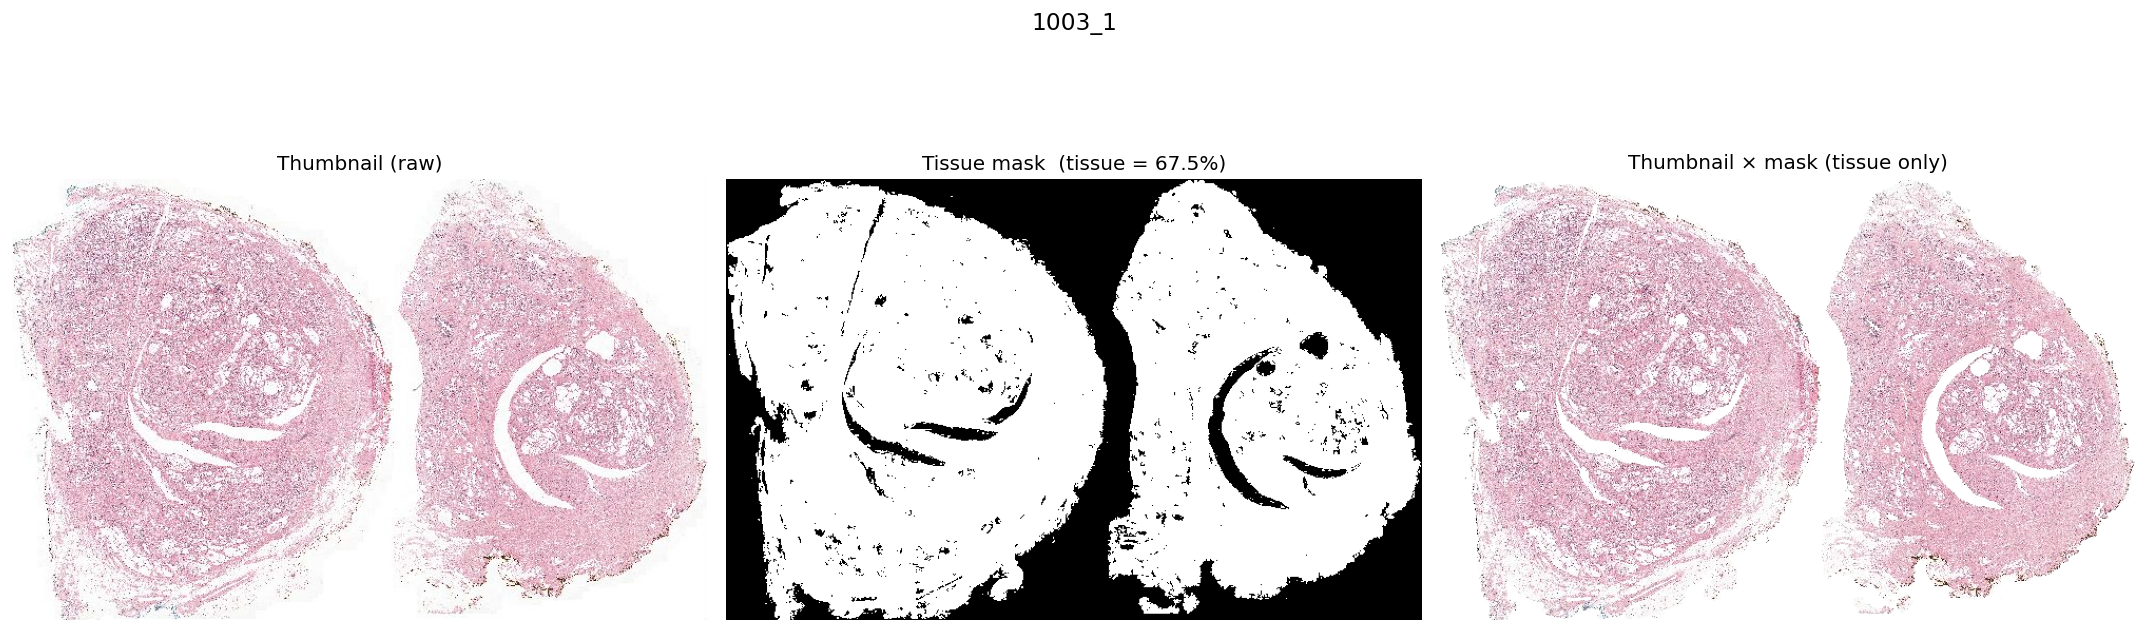

In [ ]:
# Apply mask directly — no resize needed, shapes are identical
masked_arr = thumb_arr.copy()
masked_arr[mask_arr == 0] = 255

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(thumb_arr)
axes[0].set_title("Thumbnail (raw)", fontsize=12)
axes[0].axis("off")

axes[1].imshow(mask_arr, cmap="gray")
axes[1].set_title(f"Tissue mask  (tissue = {mask_arr.mean():.1%})", fontsize=12)
axes[1].axis("off")

axes[2].imshow(masked_arr)
axes[2].set_title("Thumbnail × mask (tissue only)", fontsize=12)
axes[2].axis("off")

plt.suptitle(f"{SAMPLE_SLIDE}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()